# 🤖 Reinforcement Learning: A Beginner's Guide
### From Zero to Q-Learning — with a Real Working Example

---

> *"Reinforcement learning is learning what to do — how to map situations to actions — so as to maximize a numerical reward signal."*  
> — Sutton & Barto, *Reinforcement Learning: An Introduction*

---

## 📚 Table of Contents
1. [What is Reinforcement Learning?](#1)
2. [The RL Framework: Agent, Environment, State, Action, Reward](#2)
3. [Key Concepts: Policies, Value Functions, and the Bellman Equation](#3)
4. [Q-Learning Explained](#4)
5. [🎮 Our Example: Teaching a Robot to Navigate a Grid World](#5)
6. [Building the Grid World Environment](#6)
7. [Implementing Q-Learning from Scratch](#7)
8. [Training the Agent & Watching it Learn](#8)
9. [Visualizing What the Agent Learned](#9)
10. [Key Takeaways & Next Steps](#10)

<a id='1'></a>
## 1. 🧠 What is Reinforcement Learning?

Imagine you're teaching a dog a new trick. You don't hand it a manual. Instead:
- The dog **tries** something
- If it does well → you give it a **treat** 🐕🦴 (reward)
- If it does poorly → no treat (or a gentle "no")
- Over time, the dog **learns** which behaviors lead to treats

**That's Reinforcement Learning (RL) in a nutshell.**

RL is one of the three main paradigms in machine learning:

| Paradigm | How it Learns | Example |
|---|---|---|
| **Supervised Learning** | From labeled examples | Classifying emails as spam/not spam |
| **Unsupervised Learning** | From patterns in unlabeled data | Customer segmentation |
| **Reinforcement Learning** | From trial-and-error + rewards | Teaching a robot to walk |

### Real-World RL Success Stories
- 🎮 **AlphaGo / AlphaZero** — Defeated world champions at Go and Chess
- 🤖 **ChatGPT (RLHF)** — Used RL with human feedback to align LLM behavior
- 🚗 **Self-Driving Cars** — Learning lane-keeping and navigation
- 🏭 **Data Center Cooling** — Google used RL to reduce cooling costs by 40%
- 📈 **Algorithmic Trading** — Optimizing buy/sell strategies

<a id='2'></a>
## 2. 🗺️ The RL Framework

Every RL problem has the same fundamental structure:

```
┌─────────────────────────────────────────────────────────────┐
│                    THE RL LOOP                              │
│                                                             │
│          State (s_t)         Action (a_t)                   │
│   ENV ──────────────► AGENT ──────────────► ENV             │
│    ▲                                         │              │
│    │     Reward (r_t+1) + Next State (s_t+1) │              │
│    └─────────────────────────────────────────┘              │
│                                                             │
└─────────────────────────────────────────────────────────────┘
```

Let's define each piece:

### 🕹️ Agent
The **learner** and decision-maker. This is our AI — it observes the world and takes actions.

### 🌍 Environment
Everything the agent interacts with. The environment responds to actions and produces new states and rewards.

### 📍 State (s)
A snapshot of the current situation. In a chess game, it's the board configuration. In a grid world, it's the robot's position.

### 🎯 Action (a)
What the agent can do. Move left, right, up, down. Buy or sell a stock. Turn a dial.

### 🏆 Reward (r)
A scalar signal telling the agent how well it did. The agent's **only goal** is to maximize cumulative reward over time.

### 📜 Episode
A complete run from start to a terminal state (e.g., game over, goal reached). RL agents learn across many episodes.

### ⏰ Discount Factor (γ — gamma)
Future rewards are worth slightly less than immediate rewards. γ ∈ [0, 1].
- γ = 0: Agent is completely shortsighted (only cares about immediate reward)
- γ = 1: Agent values future rewards equally to present rewards
- Typical value: γ = 0.9 or 0.99

**Cumulative Return** (what the agent actually maximizes):
$$G_t = r_{t+1} + \gamma r_{t+2} + \gamma^2 r_{t+3} + ... = \sum_{k=0}^{\infty} \gamma^k r_{t+k+1}$$

<a id='3'></a>
## 3. 📐 Key Concepts: Policies, Value Functions & the Bellman Equation

### 📋 Policy (π)
A **policy** is the agent's strategy — a mapping from states to actions.
- **Deterministic policy**: π(s) = a (always take action a in state s)
- **Stochastic policy**: π(a|s) = probability of taking action a in state s

The agent's goal: find the **optimal policy π*** that maximizes cumulative reward.

---

### 💰 Value Functions

Value functions answer: *"How good is it to be in a certain state (or to take a certain action)?"*

**State-Value Function V(s):**  
Expected cumulative reward starting from state s, following policy π.
$$V^{\pi}(s) = \mathbb{E}_{\pi}[G_t | S_t = s]$$

**Action-Value Function Q(s, a)** (the Q in Q-learning!):  
Expected cumulative reward starting from state s, taking action a, then following policy π.
$$Q^{\pi}(s, a) = \mathbb{E}_{\pi}[G_t | S_t = s, A_t = a]$$

---

### 🔔 The Bellman Equation
The Bellman equation is the **fundamental recursive relationship** in RL. It says:

*"The value of a state = immediate reward + discounted value of the next state"*

$$V^*(s) = \max_a \left[ r(s,a) + \gamma \sum_{s'} P(s'|s,a) V^*(s') \right]$$

For Q-values:
$$Q^*(s, a) = r(s,a) + \gamma \max_{a'} Q^*(s', a')$$

This recursive definition is the foundation of Q-learning!

<a id='4'></a>
## 4. 🔑 Q-Learning Explained

**Q-Learning** (Watkins, 1989) is a classic, model-free RL algorithm. "Model-free" means the agent doesn't need to know the environment's rules in advance — it learns purely from experience.

### The Q-Table
Q-learning maintains a **Q-Table**: a lookup table with a row for every state and a column for every action.

```
         UP    DOWN   LEFT   RIGHT
State 0 [ 0.1,  0.5,  -0.2,   0.8 ]
State 1 [ 0.3,  0.1,   0.9,   0.2 ]
State 2 [ 0.0,  1.0,   0.3,   0.5 ]
  ...                               
```

Each cell Q(s, a) stores *"how valuable is it to take action a in state s?"*

### The Q-Learning Update Rule

After taking action a in state s, receiving reward r, and landing in state s':

$$Q(s,a) \leftarrow Q(s,a) + \alpha \left[ r + \gamma \max_{a'} Q(s',a') - Q(s,a) \right]$$

Breaking it down:
| Term | Meaning |
|---|---|
| α (alpha) | **Learning rate** — how fast we update (0 = no learning, 1 = overwrite completely) |
| r + γ max Q(s', a') | **TD Target** — our new estimate of the true Q-value |
| Q(s,a) (subtracted) | **Old estimate** |
| [Target - Old estimate] | **TD Error** — how wrong we were; drives the update |

### ⚖️ Exploration vs. Exploitation Dilemma
A critical challenge in RL:
- **Exploit**: Use what you know — pick the action with the highest Q-value
- **Explore**: Try new things — you might discover something better!

**ε-greedy Strategy**: With probability ε, take a random action (explore). Otherwise, take the best known action (exploit). We typically start with ε ≈ 1.0 (lots of exploration) and decay it over time.

```
HIGH EXPLORATION (ε=1.0)          LOW EXPLORATION (ε=0.05)
Early Training                     Late Training
"Try everything!"                  "Stick to what works."
```

<a id='5'></a>
## 5. 🎮 Our Example: The Grid World

We'll teach an agent to navigate a **5×5 Grid World**:

```
┌─────┬─────┬─────┬─────┬─────┐
│  S  │     │     │  W  │     │
├─────┼─────┼─────┼─────┼─────┤
│     │  W  │     │     │     │
├─────┼─────┼─────┼─────┼─────┤
│     │     │  W  │     │     │
├─────┼─────┼─────┼─────┼─────┤
│     │     │     │  W  │     │
├─────┼─────┼─────┼─────┼─────┤
│     │     │     │     │  G  │
└─────┴─────┴─────┴─────┴─────┘

S = Start   W = Wall/Trap   G = Goal
```

### Rules:
- The agent starts at position **S** (top-left)
- Goal: reach **G** (bottom-right) with maximum reward
- **Actions**: UP, DOWN, LEFT, RIGHT
- **Rewards**:
  - Reach Goal: **+10** 🏆
  - Hit a Wall/Trap: **-5** 💀
  - Every step taken: **-0.1** (encourages efficiency)
  - Hit boundary: **-0.5** (stay in bounds!)

In [1]:
# ── Install / import dependencies ──────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# Set consistent style
plt.rcParams.update({
    'figure.facecolor': '#1a1a2e',
    'axes.facecolor':   '#16213e',
    'axes.edgecolor':   '#0f3460',
    'text.color':       '#e0e0e0',
    'axes.labelcolor':  '#e0e0e0',
    'xtick.color':      '#e0e0e0',
    'ytick.color':      '#e0e0e0',
    'font.family':      'monospace',
})

print("✅ Libraries loaded successfully!")
print(f"   NumPy  version: {np.__version__}")
print(f"   Matplotlib version: {plt.matplotlib.__version__}")

✅ Libraries loaded successfully!
   NumPy  version: 1.26.4
   Matplotlib version: 3.7.2


<a id='6'></a>
## 6. 🏗️ Building the Grid World Environment

In [2]:
class GridWorld:
    """
    A 5x5 Grid World environment.
    
    Layout:
        S = Start (0,0)     G = Goal (4,4)
        W = Walls/Traps at positions (0,3), (1,1), (2,2), (3,3)
    
    Actions: 0=UP, 1=DOWN, 2=LEFT, 3=RIGHT
    """
    
    # Action constants
    UP, DOWN, LEFT, RIGHT = 0, 1, 2, 3
    ACTION_NAMES = ['↑ UP', '↓ DOWN', '← LEFT', '→ RIGHT']
    
    def __init__(self, size=5):
        self.size        = size
        self.n_states    = size * size          # 25 states
        self.n_actions   = 4
        
        # Define special cells
        self.start  = (0, 0)
        self.goal   = (size-1, size-1)
        self.traps  = {(0, 3), (1, 1), (2, 2), (3, 3)}  # walls / traps
        
        # Rewards
        self.reward_goal     =  10.0
        self.reward_trap     =  -5.0
        self.reward_step     =  -0.1
        self.reward_boundary =  -0.5
        
        self.state = self.start   # current position (row, col)
    
    # ── Helpers ────────────────────────────────────────────────────────────
    def pos_to_state(self, row, col):
        """Convert (row, col) position to a flat state index."""
        return row * self.size + col
    
    def state_to_pos(self, state):
        """Convert flat state index back to (row, col)."""
        return divmod(state, self.size)
    
    def get_state_index(self):
        return self.pos_to_state(*self.state)
    
    # ── Core RL Interface ──────────────────────────────────────────────────
    def reset(self):
        """Reset environment to start; return initial state index."""
        self.state = self.start
        return self.get_state_index()
    
    def step(self, action):
        """
        Take one action. Returns (next_state, reward, done).
        """
        row, col = self.state
        
        # Compute intended next position
        if   action == self.UP:    new_row, new_col = row - 1, col
        elif action == self.DOWN:  new_row, new_col = row + 1, col
        elif action == self.LEFT:  new_row, new_col = row, col - 1
        elif action == self.RIGHT: new_row, new_col = row, col + 1
        
        # Boundary check
        hit_boundary = not (0 <= new_row < self.size and 0 <= new_col < self.size)
        if hit_boundary:
            new_row, new_col = row, col   # stay put
            reward = self.reward_boundary
            done   = False
        elif (new_row, new_col) == self.goal:
            reward = self.reward_goal
            done   = True
        elif (new_row, new_col) in self.traps:
            reward = self.reward_trap
            done   = True
        else:
            reward = self.reward_step
            done   = False
        
        self.state = (new_row, new_col)
        return self.get_state_index(), reward, done
    
    # ── Visualisation ──────────────────────────────────────────────────────
    def render(self, ax=None, title='Grid World', agent_state=None,
               q_table=None, show_values=False):
        """
        Draw the grid. If q_table is provided, overlay the best-action arrows.
        """
        if ax is None:
            fig, ax = plt.subplots(figsize=(6, 6))
        
        ax.set_xlim(0, self.size)
        ax.set_ylim(0, self.size)
        ax.set_aspect('equal')
        ax.set_title(title, fontsize=14, fontweight='bold', color='#e0e0e0', pad=10)
        ax.axis('off')
        
        # Color scheme
        colors = {
            'empty':    '#1e3a5f',
            'start':    '#2ecc71',
            'goal':     '#f39c12',
            'trap':     '#e74c3c',
            'agent':    '#9b59b6',
            'grid_line':'#0f3460',
        }
        
        for row in range(self.size):
            for col in range(self.size):
                pos = (row, col)
                # Flip row so (0,0) is top-left
                draw_row = self.size - 1 - row
                
                if pos == self.goal:
                    color = colors['goal']
                    label = '🏆'
                elif pos in self.traps:
                    color = colors['trap']
                    label = '💀'
                elif pos == self.start:
                    color = colors['start']
                    label = 'S'
                else:
                    color = colors['empty']
                    label = ''
                
                # Draw cell
                rect = mpatches.FancyBboxPatch(
                    (col + 0.05, draw_row + 0.05),
                    0.90, 0.90,
                    boxstyle='round,pad=0.04',
                    linewidth=1, edgecolor=colors['grid_line'],
                    facecolor=color, alpha=0.9, zorder=1
                )
                ax.add_patch(rect)
                
                if label:
                    ax.text(col + 0.5, draw_row + 0.5, label,
                            ha='center', va='center', fontsize=18, zorder=3)
                
                # State number (small)
                state_idx = self.pos_to_state(row, col)
                ax.text(col + 0.12, draw_row + 0.85,
                        str(state_idx), fontsize=7,
                        color='#aaaaaa', zorder=3)
                
                # Q-value best action arrow
                if q_table is not None and pos not in self.traps and pos != self.goal:
                    best_action = np.argmax(q_table[state_idx])
                    dxdy = {self.UP:(0,0.25), self.DOWN:(0,-0.25),
                            self.LEFT:(-0.25,0), self.RIGHT:(0.25,0)}
                    dx, dy = dxdy[best_action]
                    ax.annotate('', xy=(col+0.5+dx, draw_row+0.5+dy),
                                xytext=(col+0.5-dx*0.4, draw_row+0.5-dy*0.4),
                                arrowprops=dict(arrowstyle='->', color='#ffffff',
                                                lw=1.8), zorder=4)
                    if show_values:
                        best_q = np.max(q_table[state_idx])
                        ax.text(col+0.5, draw_row+0.15,
                                f'{best_q:.2f}', ha='center', va='center',
                                fontsize=7, color='#f0c040', zorder=5)
        
        # Draw agent
        if agent_state is not None:
            ag_row, ag_col = self.state_to_pos(agent_state)
            draw_ag_row = self.size - 1 - ag_row
            circle = plt.Circle((ag_col + 0.5, draw_ag_row + 0.5),
                                 0.28, color=colors['agent'], zorder=5, alpha=0.95)
            ax.add_patch(circle)
            ax.text(ag_col + 0.5, draw_ag_row + 0.5, '🤖',
                    ha='center', va='center', fontsize=16, zorder=6)
        
        return ax


# ── Quick sanity check ─────────────────────────────────────────────────────
env = GridWorld()
print("Environment created!")
print(f"  Grid size    : {env.size}×{env.size}")
print(f"  Total states : {env.n_states}")
print(f"  Actions      : {env.n_actions} ({', '.join(env.ACTION_NAMES)})")
print(f"  Start state  : {env.start} → index {env.pos_to_state(*env.start)}")
print(f"  Goal state   : {env.goal}  → index {env.pos_to_state(*env.goal)}")
print(f"  Trap states  : {env.traps}")

# Test a step
s0 = env.reset()
s1, r, done = env.step(env.RIGHT)
print(f"\nTest step: State {s0} → RIGHT → State {s1}, Reward={r}, Done={done}")

Environment created!
  Grid size    : 5×5
  Total states : 25
  Actions      : 4 (↑ UP, ↓ DOWN, ← LEFT, → RIGHT)
  Start state  : (0, 0) → index 0
  Goal state   : (4, 4)  → index 24
  Trap states  : {(1, 1), (0, 3), (3, 3), (2, 2)}

Test step: State 0 → RIGHT → State 1, Reward=-0.1, Done=False


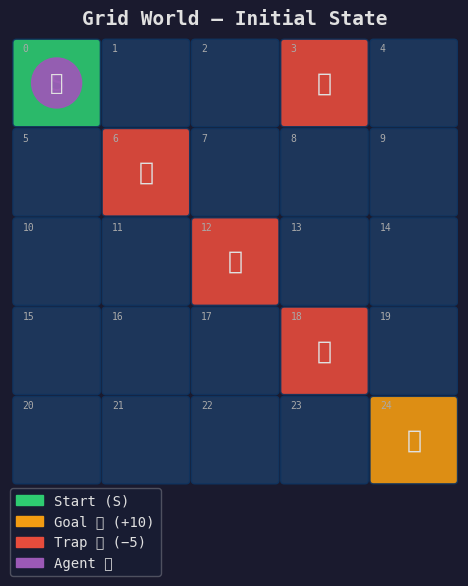

Grid world visualised.  Numbers in top-left corners are state indices.


In [3]:
# ── Visualise the initial grid ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 6),
                        facecolor='#1a1a2e')
env.render(ax=ax,
           title='Grid World — Initial State',
           agent_state=env.reset())

# Legend
legend_items = [
    mpatches.Patch(color='#2ecc71', label='Start (S)'),
    mpatches.Patch(color='#f39c12', label='Goal 🏆 (+10)'),
    mpatches.Patch(color='#e74c3c', label='Trap 💀 (−5)'),
    mpatches.Patch(color='#9b59b6', label='Agent 🤖'),
]
ax.legend(handles=legend_items, loc='lower left',
          framealpha=0.3, fontsize=10,
          bbox_to_anchor=(-0.02, -0.22))

plt.tight_layout()
plt.savefig('grid_world_initial.png', dpi=150, bbox_inches='tight',
            facecolor='#1a1a2e')
plt.show()
print("Grid world visualised.  Numbers in top-left corners are state indices.")

<a id='7'></a>
## 7. 🧮 Implementing Q-Learning from Scratch

In [4]:
class QLearningAgent:
    """
    Tabular Q-Learning Agent with ε-greedy exploration.
    
    Core update rule:
        Q(s,a) ← Q(s,a) + α * [r + γ * max_a' Q(s',a') - Q(s,a)]
    """
    
    def __init__(self, n_states, n_actions,
                 alpha=0.1,    # learning rate
                 gamma=0.99,   # discount factor
                 epsilon=1.0,  # initial exploration rate
                 epsilon_decay=0.995,
                 epsilon_min=0.01,
                 seed=42):
        
        np.random.seed(seed)
        self.n_states      = n_states
        self.n_actions     = n_actions
        self.alpha         = alpha
        self.gamma         = gamma
        self.epsilon       = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min   = epsilon_min
        
        # ── Q-Table: initialise to zeros ──────────────────────────────────
        # Shape: (n_states, n_actions) = (25, 4)
        self.Q = np.zeros((n_states, n_actions))
        
        # Tracking
        self.epsilon_history = []
    
    def select_action(self, state):
        """
        ε-greedy action selection:
          With probability ε  → random action  (explore)
          With probability 1-ε→ best Q action  (exploit)
        """
        if np.random.random() < self.epsilon:
            return np.random.randint(self.n_actions)   # explore
        else:
            return np.argmax(self.Q[state])             # exploit
    
    def update(self, state, action, reward, next_state, done):
        """
        Q-learning update.
        If done (terminal), there is no next state — target = r only.
        """
        current_q  = self.Q[state, action]
        
        if done:
            target = reward
        else:
            target = reward + self.gamma * np.max(self.Q[next_state])
        
        td_error = target - current_q
        self.Q[state, action] += self.alpha * td_error
        
        return td_error   # useful for monitoring
    
    def decay_epsilon(self):
        """Reduce exploration rate after each episode."""
        self.epsilon = max(self.epsilon_min,
                           self.epsilon * self.epsilon_decay)
        self.epsilon_history.append(self.epsilon)
    
    def get_policy(self):
        """Return the greedy policy: best action for each state."""
        return np.argmax(self.Q, axis=1)


# ── Instantiate agent ──────────────────────────────────────────────────────
agent = QLearningAgent(
    n_states  = env.n_states,
    n_actions = env.n_actions,
    alpha         = 0.1,
    gamma         = 0.99,
    epsilon       = 1.0,
    epsilon_decay = 0.995,
    epsilon_min   = 0.01,
)

print("Agent created!")
print(f"  Q-table shape : {agent.Q.shape}  (states × actions)")
print(f"  Learning rate : α = {agent.alpha}")
print(f"  Discount      : γ = {agent.gamma}")
print(f"  Exploration   : ε = {agent.epsilon} (will decay to {agent.epsilon_min})")
print(f"\nInitial Q-table (all zeros):")
print(agent.Q)

Agent created!
  Q-table shape : (25, 4)  (states × actions)
  Learning rate : α = 0.1
  Discount      : γ = 0.99
  Exploration   : ε = 1.0 (will decay to 0.01)

Initial Q-table (all zeros):
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


<a id='8'></a>
## 8. 🚀 Training the Agent & Watching It Learn

In [5]:
def train(env, agent, n_episodes=2000, max_steps=100):
    """
    Run Q-learning for n_episodes.
    Returns history dict for analysis.
    """
    history = {
        'episode_rewards': [],
        'episode_lengths': [],
        'success_flags':   [],   # did the agent reach the goal?
        'snapshots':       {},   # Q-table snapshots at key points
    }
    
    snapshot_episodes = {50, 200, 500, 1000, n_episodes}
    
    for ep in range(1, n_episodes + 1):
        state        = env.reset()
        total_reward = 0
        steps        = 0
        
        for _ in range(max_steps):
            action                     = agent.select_action(state)
            next_state, reward, done   = env.step(action)
            agent.update(state, action, reward, next_state, done)
            
            state         = next_state
            total_reward += reward
            steps        += 1
            
            if done:
                break
        
        agent.decay_epsilon()
        
        goal_pos  = env.pos_to_state(*env.goal)
        succeeded = (state == goal_pos)
        
        history['episode_rewards'].append(total_reward)
        history['episode_lengths'].append(steps)
        history['success_flags'].append(succeeded)
        
        if ep in snapshot_episodes:
            history['snapshots'][ep] = agent.Q.copy()
        
        if ep % 500 == 0:
            recent_success = np.mean(history['success_flags'][-100:]) * 100
            print(f"  Episode {ep:5d} | "
                  f"Avg reward (last 100): {np.mean(history['episode_rewards'][-100:]):6.2f} | "
                  f"ε = {agent.epsilon:.4f} | "
                  f"Success rate (last 100): {recent_success:.1f}%")
    
    return history


print("🚀 Training Q-Learning Agent on Grid World...")
print("=" * 72)
history = train(env, agent, n_episodes=2000)
print("=" * 72)
print("✅ Training complete!")

final_success = np.mean(history['success_flags'][-100:]) * 100
print(f"\nFinal 100-episode success rate : {final_success:.1f}%")
print(f"Final average reward           : {np.mean(history['episode_rewards'][-100:]):.2f}")

🚀 Training Q-Learning Agent on Grid World...
  Episode   500 | Avg reward (last 100):   8.52 | ε = 0.0816 | Success rate (last 100): 96.0%
  Episode  1000 | Avg reward (last 100):   9.27 | ε = 0.0100 | Success rate (last 100): 100.0%
  Episode  1500 | Avg reward (last 100):   9.29 | ε = 0.0100 | Success rate (last 100): 100.0%
  Episode  2000 | Avg reward (last 100):   9.14 | ε = 0.0100 | Success rate (last 100): 99.0%
✅ Training complete!

Final 100-episode success rate : 99.0%
Final average reward           : 9.14


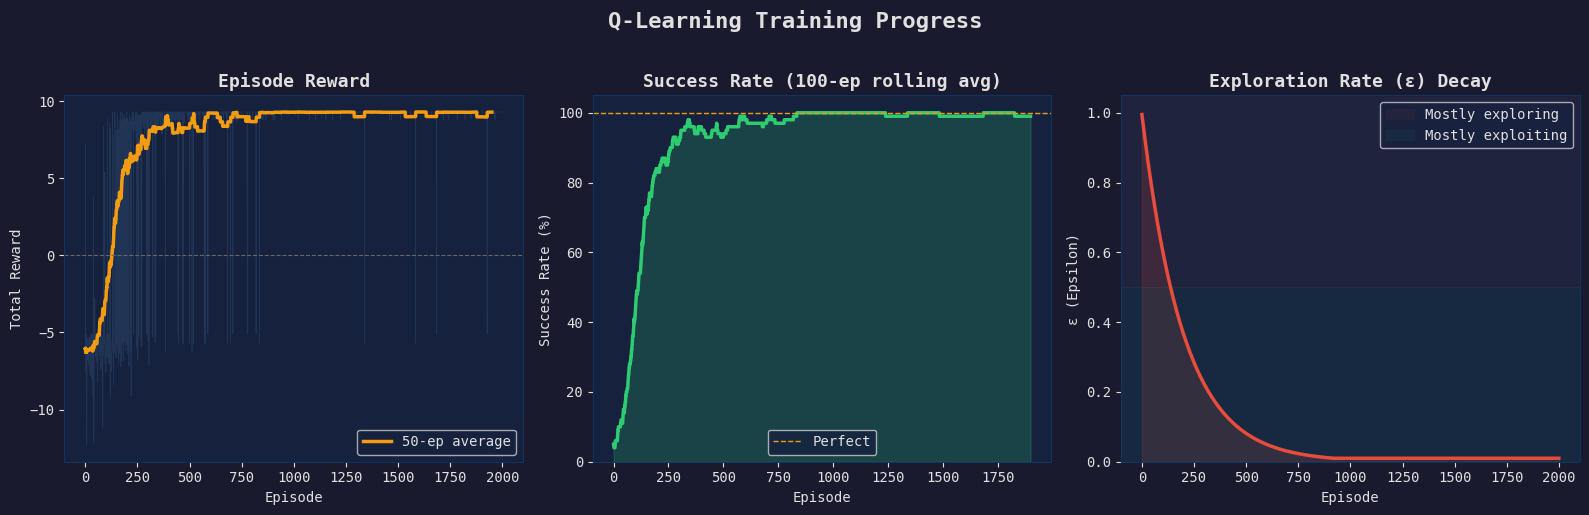

In [6]:
# ── Training curves ────────────────────────────────────────────────────────
def smooth(x, w=50):
    """Simple moving average."""
    return np.convolve(x, np.ones(w)/w, mode='valid')

fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor='#1a1a2e')

episodes  = np.arange(len(history['episode_rewards']))
rewards   = np.array(history['episode_rewards'])
lengths   = np.array(history['episode_lengths'])
successes = np.array(history['success_flags'], dtype=float)

# ── Panel 1: Episode Rewards ───────────────────────────────────────────────
ax = axes[0]
ax.plot(episodes, rewards, alpha=0.15, color='#5dade2', linewidth=0.5)
ax.plot(np.arange(len(smooth(rewards))), smooth(rewards),
        color='#f39c12', linewidth=2.5, label='50-ep average')
ax.set_title('Episode Reward', fontsize=13, fontweight='bold')
ax.set_xlabel('Episode')
ax.set_ylabel('Total Reward')
ax.legend(fontsize=10)
ax.axhline(0, color='#666', linestyle='--', linewidth=0.8)

# ── Panel 2: Success Rate ──────────────────────────────────────────────────
ax = axes[1]
rolling_success = smooth(successes * 100, w=100)
ax.plot(np.arange(len(rolling_success)), rolling_success,
        color='#2ecc71', linewidth=2.5)
ax.fill_between(np.arange(len(rolling_success)), rolling_success,
                alpha=0.2, color='#2ecc71')
ax.set_title('Success Rate (100-ep rolling avg)', fontsize=13, fontweight='bold')
ax.set_xlabel('Episode')
ax.set_ylabel('Success Rate (%)')
ax.set_ylim(0, 105)
ax.axhline(100, color='#f39c12', linestyle='--', linewidth=1, label='Perfect')
ax.legend(fontsize=10)

# ── Panel 3: Epsilon Decay ─────────────────────────────────────────────────
ax = axes[2]
ax.plot(agent.epsilon_history, color='#e74c3c', linewidth=2.5)
ax.fill_between(range(len(agent.epsilon_history)), agent.epsilon_history,
                alpha=0.15, color='#e74c3c')
ax.set_title('Exploration Rate (ε) Decay', fontsize=13, fontweight='bold')
ax.set_xlabel('Episode')
ax.set_ylabel('ε (Epsilon)')
ax.set_ylim(0, 1.05)
# annotate regions
ax.axhspan(0.5, 1.05, alpha=0.05, color='#e74c3c', label='Mostly exploring')
ax.axhspan(0, 0.5,  alpha=0.05, color='#2ecc71', label='Mostly exploiting')
ax.legend(fontsize=10)

for ax in axes:
    ax.set_facecolor('#16213e')
    ax.spines[:].set_color('#0f3460')

plt.suptitle('Q-Learning Training Progress', fontsize=16,
             fontweight='bold', color='#e0e0e0', y=1.02)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight',
            facecolor='#1a1a2e')
plt.show()

### 📊 Reading the Training Curves

| Panel | What it shows |
|---|---|
| **Reward** | Starts low/negative (random wandering). Rises steadily as the agent learns. |
| **Success Rate** | Starts near 0%. Should climb to 80–100% as training progresses. |
| **Epsilon** | Decays from 1.0 → 0.01. High early (explore) → low later (exploit). |

<a id='9'></a>
## 9. 🔍 Visualising What the Agent Learned

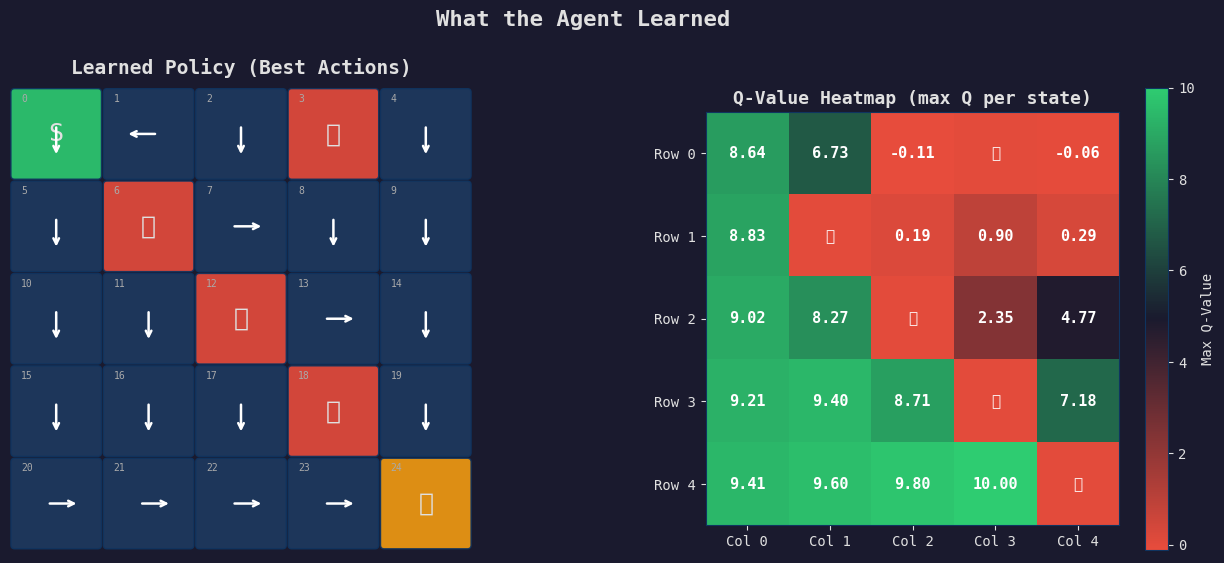

In [7]:
# ── Learned Policy & Q-values ──────────────────────────────────────────────
fig = plt.figure(figsize=(16, 6), facecolor='#1a1a2e')
gs  = gridspec.GridSpec(1, 2, wspace=0.4)

# ── Left: Learned Policy (arrows) ─────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
env.render(ax=ax1, title='Learned Policy (Best Actions)',
           q_table=agent.Q, show_values=False)

# ── Right: Q-value heatmap (max Q per state) ───────────────────────────────
ax2 = fig.add_subplot(gs[1])

max_q_grid = np.max(agent.Q, axis=1).reshape(env.size, env.size)
# Mask traps and goal for cleaner display
display_grid = max_q_grid.copy()

cmap = LinearSegmentedColormap.from_list(
    'rl', ['#e74c3c', '#1a1a2e', '#2ecc71'])

im = ax2.imshow(display_grid, cmap=cmap, aspect='equal')
plt.colorbar(im, ax=ax2, label='Max Q-Value')

for row in range(env.size):
    for col in range(env.size):
        pos = (row, col)
        val = display_grid[row, col]
        label = f'{val:.2f}'
        if pos == env.goal:
            label = '🏆'
        elif pos in env.traps:
            label = '💀'
        ax2.text(col, row, label, ha='center', va='center',
                 fontsize=11, color='white', fontweight='bold')

ax2.set_title('Q-Value Heatmap (max Q per state)',
              fontsize=13, fontweight='bold', color='#e0e0e0')
ax2.set_xticks(range(env.size))
ax2.set_yticks(range(env.size))
ax2.set_xticklabels([f'Col {i}' for i in range(env.size)])
ax2.set_yticklabels([f'Row {i}' for i in range(env.size)])
ax2.set_facecolor('#16213e')

plt.suptitle('What the Agent Learned', fontsize=16,
             fontweight='bold', color='#e0e0e0', y=1.01)
plt.savefig('learned_policy.png', dpi=150, bbox_inches='tight',
            facecolor='#1a1a2e')
plt.show()

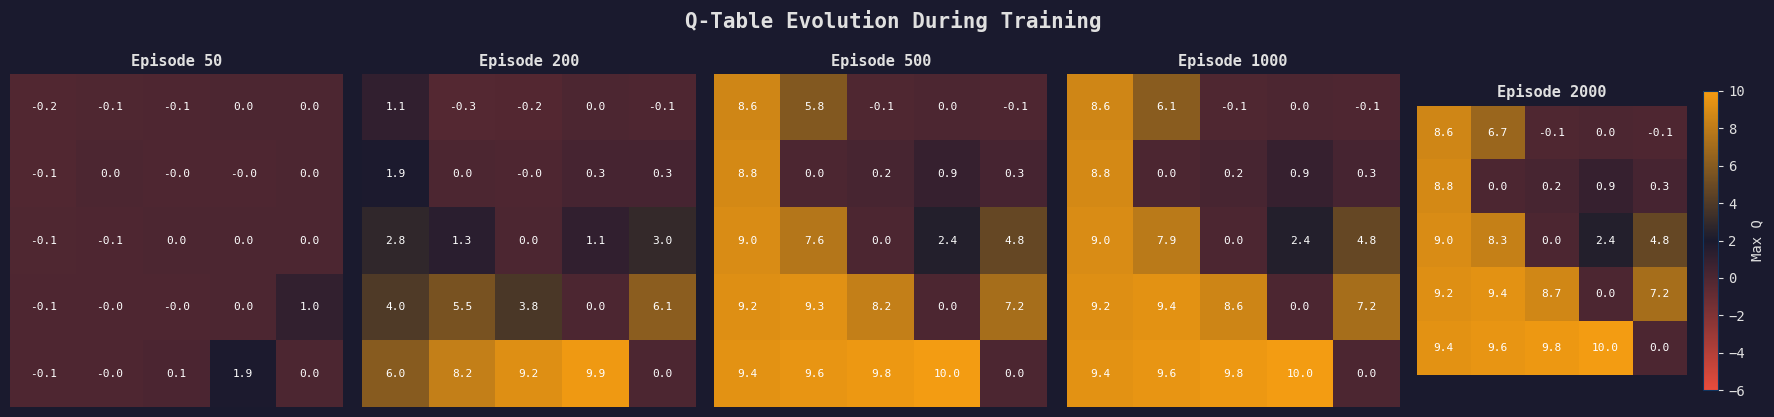

Notice how Q-values go from uniform (Episode 50) to structured (Episode 2000)!


In [8]:
# ── Q-table evolution across training ─────────────────────────────────────
snapshots = history['snapshots']
snap_keys = sorted(snapshots.keys())

fig, axes = plt.subplots(1, len(snap_keys), figsize=(18, 4),
                          facecolor='#1a1a2e')

cmap = LinearSegmentedColormap.from_list('rl2',
            ['#e74c3c', '#1a1a2e', '#f39c12'])

for ax, ep in zip(axes, snap_keys):
    q_snap = snapshots[ep]
    max_q  = np.max(q_snap, axis=1).reshape(env.size, env.size)
    im     = ax.imshow(max_q, cmap=cmap, aspect='equal',
                       vmin=-6, vmax=10)
    ax.set_title(f'Episode {ep}', fontsize=11,
                 fontweight='bold', color='#e0e0e0')
    ax.axis('off')
    
    for row in range(env.size):
        for col in range(env.size):
            val = max_q[row, col]
            ax.text(col, row, f'{val:.1f}', ha='center', va='center',
                    fontsize=8, color='white')

plt.colorbar(im, ax=axes[-1], shrink=0.9, label='Max Q')
plt.suptitle('Q-Table Evolution During Training',
             fontsize=15, fontweight='bold', color='#e0e0e0', y=1.03)
plt.tight_layout()
plt.savefig('q_table_evolution.png', dpi=150, bbox_inches='tight',
            facecolor='#1a1a2e')
plt.show()
print("Notice how Q-values go from uniform (Episode 50) to structured (Episode 2000)!")

🤖 Agent's learned path (greedy):
   Position sequence: (0, 0) → (1, 0) → (2, 0) → (3, 0) → (4, 0) → (4, 1) → (4, 2) → (4, 3) → (4, 4)
   Steps taken      : 8
   Total reward     : 9.30
   Reached goal?    : True


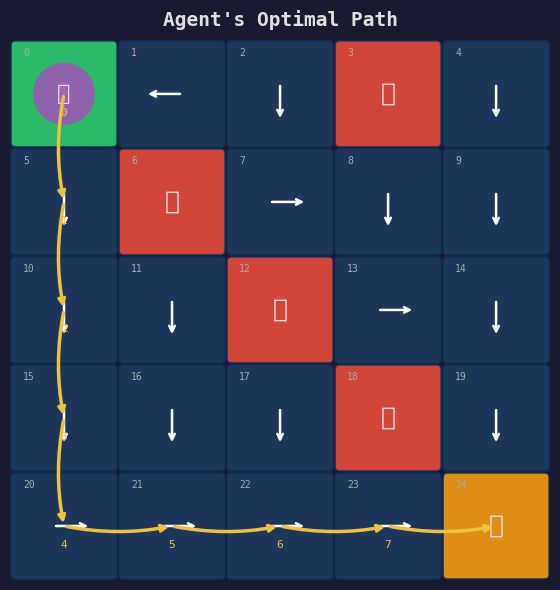

In [9]:
# ── Run a test episode and show the path ──────────────────────────────────
def run_episode_greedy(env, agent, max_steps=50):
    """Run one fully greedy (no exploration) episode. Return path."""
    state = env.reset()
    path  = [env.state]
    total_reward = 0
    
    for step in range(max_steps):
        action = np.argmax(agent.Q[state])   # always exploit
        next_state, reward, done = env.step(action)
        path.append(env.state)
        total_reward += reward
        state = next_state
        if done:
            break
    
    return path, total_reward


path, total_r = run_episode_greedy(env, agent)
print("🤖 Agent's learned path (greedy):")
print("   Position sequence:", " → ".join(str(p) for p in path))
print(f"   Steps taken      : {len(path) - 1}")
print(f"   Total reward     : {total_r:.2f}")
print(f"   Reached goal?    : {path[-1] == env.goal}")

# Visualise the path
fig, ax = plt.subplots(figsize=(6, 6), facecolor='#1a1a2e')
env.render(ax=ax, title='Agent\'s Optimal Path', q_table=agent.Q)

# Draw path
for i in range(len(path) - 1):
    r1, c1 = path[i]
    r2, c2 = path[i+1]
    dr1 = env.size - 1 - r1
    dr2 = env.size - 1 - r2
    ax.annotate('',
                xy=(c2 + 0.5, dr2 + 0.5),
                xytext=(c1 + 0.5, dr1 + 0.5),
                arrowprops=dict(arrowstyle='->', color='#f0c040',
                                lw=2.5, connectionstyle='arc3,rad=0.1'),
                zorder=7)
    ax.text(c1 + 0.5, dr1 + 0.3, str(i),
            ha='center', fontsize=8, color='#f0c040', zorder=8)

# Mark start of greedy run
r0, c0 = path[0]
dr0    = env.size - 1 - r0
circ   = plt.Circle((c0 + 0.5, dr0 + 0.5), 0.28,
                     color='#9b59b6', zorder=5, alpha=0.9)
ax.add_patch(circ)
ax.text(c0 + 0.5, dr0 + 0.5, '🤖', ha='center', va='center',
        fontsize=16, zorder=6)

plt.tight_layout()
plt.savefig('optimal_path.png', dpi=150, bbox_inches='tight',
            facecolor='#1a1a2e')
plt.show()

In [10]:
# ── Print the final Q-table in a readable way ──────────────────────────────
print("📊 Final Q-Table (rounded to 2 decimals):")
print(f"{'State':>6} | {'↑ UP':>7} {'↓ DOWN':>7} {'← LEFT':>7} {'→ RIGHT':>7} | {'Best Action':>12}")
print("-" * 65)

for s in range(env.n_states):
    row, col  = env.state_to_pos(s)
    pos       = (row, col)
    best_a    = np.argmax(agent.Q[s])
    qs        = agent.Q[s]
    
    tag = ''
    if pos == env.goal:   tag = ' 🏆'
    elif pos in env.traps: tag = ' 💀'
    elif pos == env.start: tag = ' 🤖'
    
    print(f"  s={s:2d} ({row},{col}){tag:<3} | "
          f"{qs[0]:7.2f} {qs[1]:7.2f} {qs[2]:7.2f} {qs[3]:7.2f} | "
          f"  {env.ACTION_NAMES[best_a]}")

📊 Final Q-Table (rounded to 2 decimals):
 State |    ↑ UP  ↓ DOWN  ← LEFT → RIGHT |  Best Action
-----------------------------------------------------------------
  s= 0 (0,0) 🤖  |    6.39    8.64    7.25    3.76 |   ↓ DOWN
  s= 1 (0,1)    |   -0.71   -4.81    6.73   -0.28 |   ← LEFT
  s= 2 (0,2)    |   -0.61   -0.11   -0.29   -4.17 |   ↓ DOWN
  s= 3 (0,3) 💀  |    0.00    0.00    0.00    0.00 |   ↑ UP
  s= 4 (0,4)    |   -0.10   -0.06   -0.95   -0.14 |   ↓ DOWN
  s= 5 (1,0)    |    5.86    8.83    7.37   -4.98 |   ↓ DOWN
  s= 6 (1,1) 💀  |    0.00    0.00    0.00    0.00 |   ↑ UP
  s= 7 (1,2)    |   -0.19   -3.43   -2.34    0.19 |   → RIGHT
  s= 8 (1,3)    |   -1.72    0.90   -0.09   -0.06 |   ↓ DOWN
  s= 9 (1,4)    |   -0.07    0.29    0.02   -0.10 |   ↓ DOWN
  s=10 (2,0)    |    7.13    9.02    6.66    6.40 |   ↓ DOWN
  s=11 (2,1)    |   -3.06    8.27    1.30   -3.26 |   ↓ DOWN
  s=12 (2,2) 💀  |    0.00    0.00    0.00    0.00 |   ↑ UP
  s=13 (2,3)    |   -0.04   -1.72   -1.35    2.35

<a id='10'></a>
## 10. 🎓 Key Takeaways & Next Steps

### What We Covered

| Concept | Summary |
|---|---|
| **RL Framework** | Agent ↔ Environment loop: observe state → take action → get reward |
| **Q-Values** | Quantify how good it is to take action a in state s |
| **Bellman Equation** | Q(s,a) = r + γ max Q(s', a') — the core recursive insight |
| **Q-Learning** | Tabular, model-free, off-policy algorithm |
| **ε-greedy** | Balance exploration (try new things) vs exploitation (use what works) |
| **Discount Factor γ** | Trade-off between short-term and long-term rewards |

---

### Limitations of Tabular Q-Learning
- 🚫 **Doesn't scale**: A 5×5 grid = 25 states. A video game has millions of states. We can't make a table that large!
- 🚫 **No generalisation**: Each state is treated independently — learning in state 5 teaches nothing about state 6.

### The Natural Extension: Deep Q-Networks (DQN)
Replace the Q-table with a **neural network** that takes the state as input and outputs Q-values for all actions:

```
State (pixels/features)
        │
        ▼
  ┌─────────────┐
  │   Neural    │
  │   Network   │   ← approximates Q(s, a) for ALL a
  └─────────────┘
        │
        ▼
  [Q(s,UP), Q(s,DOWN), Q(s,LEFT), Q(s,RIGHT)]
```

**DQN** (Mnih et al., 2015) used this to achieve superhuman performance on 49 Atari games — a landmark result!

---

### 🗺️ RL Learning Roadmap

```
You are here
     │
     ▼
[1] Tabular Q-Learning (this notebook!)
     │
     ▼
[2] Deep Q-Networks (DQN)   ← neural network approximation
     │
     ▼
[3] Policy Gradient Methods (REINFORCE, PPO, A3C)
     │
     ▼
[4] Actor-Critic Methods (A2C, SAC, TD3)
     │
     ▼
[5] Advanced Topics: RLHF, Multi-Agent RL, Model-Based RL
```

---

### 📚 Recommended Resources
- 📖 **Sutton & Barto** — *Reinforcement Learning: An Introduction* (free online!)
- 🎮 **OpenAI Gymnasium** — Standard environments for RL research
- 🤗 **Stable-Baselines3** — Production-grade RL implementations in PyTorch
- 🎓 **DeepMind x UCL Lectures** — Free on YouTube

---

> *"The agent's goal is not to maximize the reward it receives in the next step, but its cumulative reward in the long run."*
> — Sutton & Barto

In [11]:
# ── 🎉 Challenge: Try modifying these parameters and re-run! ───────────────
print("🎯 CHALLENGES FOR THE STUDENT:")
print()
print("1. Change alpha (learning rate) to 0.5 or 0.01. What happens?")
print("2. Change gamma (discount) to 0.5. Does the agent still find the goal?")
print("3. Change epsilon_decay to 0.999 (slower decay). Compare training curves.")
print("4. Add more traps to the grid. Can the agent still navigate?")
print("5. Make the grid 7x7 instead of 5x5. How many episodes does it need?")
print()
print("Key hyperparameters to experiment with:")
print("  alpha         = 0.1   (learning rate)")
print("  gamma         = 0.99  (discount factor)")
print("  epsilon_decay = 0.995 (exploration decay speed)")
print("  n_episodes    = 2000  (total training episodes)")

🎯 CHALLENGES FOR THE STUDENT:

1. Change alpha (learning rate) to 0.5 or 0.01. What happens?
2. Change gamma (discount) to 0.5. Does the agent still find the goal?
3. Change epsilon_decay to 0.999 (slower decay). Compare training curves.
4. Add more traps to the grid. Can the agent still navigate?
5. Make the grid 7x7 instead of 5x5. How many episodes does it need?

Key hyperparameters to experiment with:
  alpha         = 0.1   (learning rate)
  gamma         = 0.99  (discount factor)
  epsilon_decay = 0.995 (exploration decay speed)
  n_episodes    = 2000  (total training episodes)
